### Steps 3 & 4: 5D Color PCA Projection & Polarity Correction

Rather than using simple, fixed color indexes, we use **Principal Component Analysis (PCA)** on a 5-dimensional color feature space:
1. **L\* Channel**: Lightness (CIELAB)
2. **a\* Channel**: Green-to-Red color variation (CIELAB)
3. **b\* Channel**: Blue-to-Yellow color variation (CIELAB)
4. **Saturation Channel**: Chroma intensity (HSV)
5. **Hue Channel**: Color family angle (HSV)

Stacking these five channels creates a 5D feature representation per pixel. Running PCA on this space finds the axis of maximum variation (**PC1**), which dynamically combines color, brightness, saturation, and hue to isolate the leaves from the background (gray pipes, grids, and shadows).

We also apply **polarity correction**: we calculate the correlation between the projected PC1 values and the original a* channel values. If they are positively correlated, we flip PC1 (multiply by -1) to guarantee that green vegetation (which has low values in a*) always corresponds to the highest values in the scaled PC1 image.

### Step 1: Load Image & Convert Color Space

Loaded image: leaf-image/veg_3/IMG_8001.JPG
Image Resolution: 1280x960


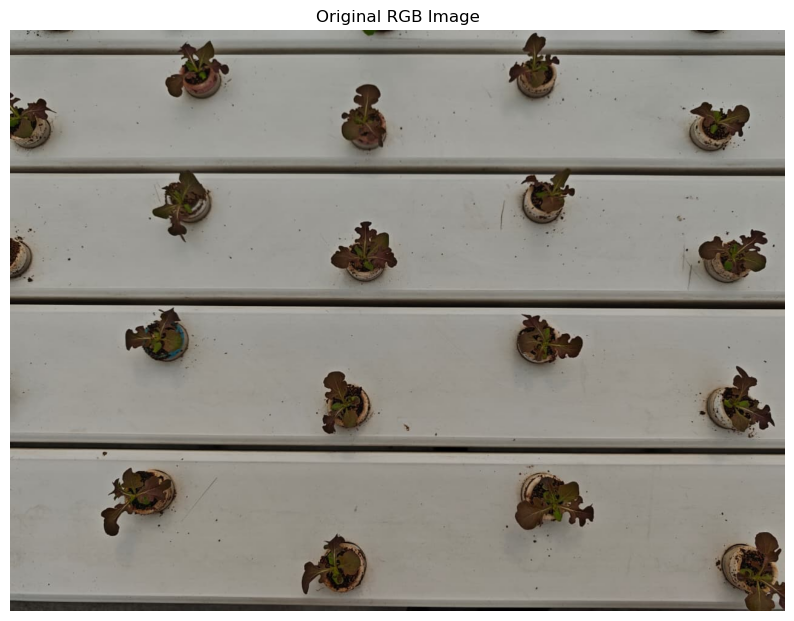

In [64]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load sample image
img_path = 'leaf-image/veg_3/IMG_8001.JPG'
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)

print(f"Loaded image: {img_path}")
print(f"Image Resolution: {img_rgb.shape[1]}x{img_rgb.shape[0]}")

# Display original image
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title("Original RGB Image")
plt.axis('off')
plt.show()

### Step 2: Channel Separation, Saturation Filtering & Visualization

We split the CIELAB image into L*, a*, and b* channels to analyze lightness and color differences:
- **L\* Channel**: Represents lightness.
- **a\* Channel**: Represents green-to-red color variation (negative values are green, positive are red).
- **b\* Channel**: Represents blue-to-yellow color variation (negative values are blue, positive are yellow).

In addition, we convert the original image to the **HSV color space** to extract the **Saturation channel**. Plants are highly saturated compared to the background elements (grow medium, white plastic grid, grey tubes, and shadows). Filtering by saturation helps isolate potential plant pixels before running PCA.

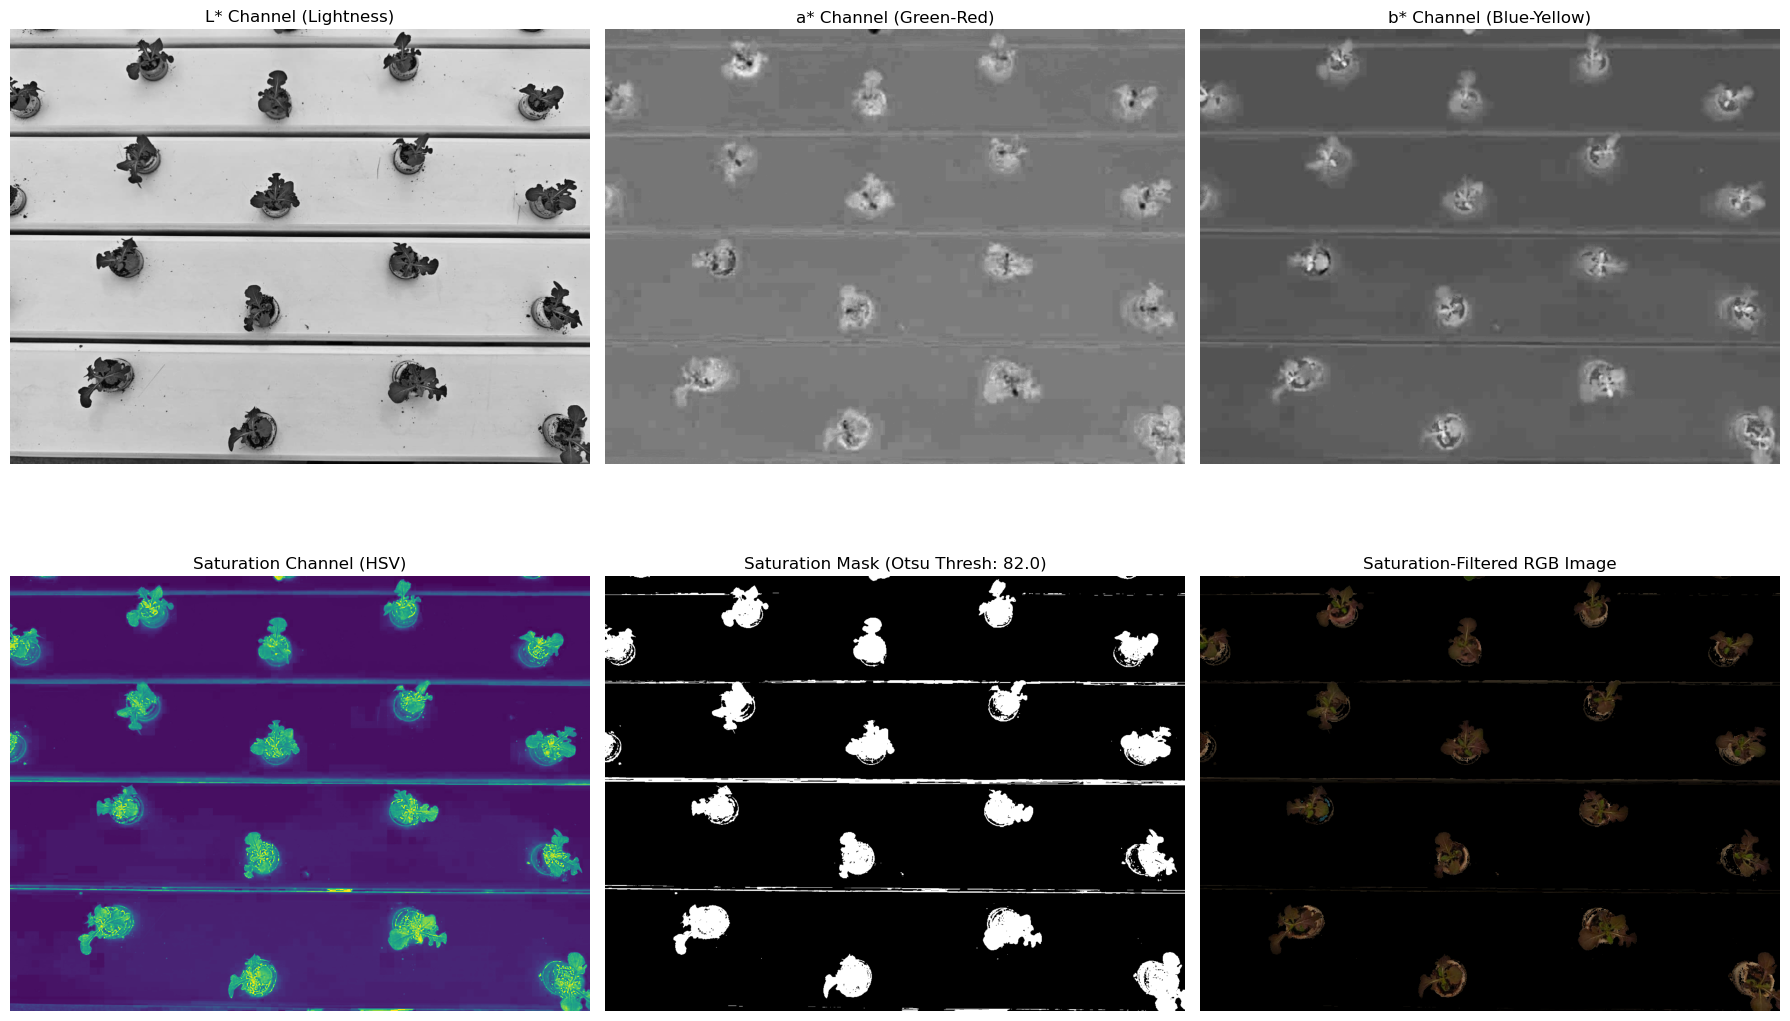

In [65]:
# 1. Split CIELAB channels
l_channel, a_channel, b_channel = cv2.split(img_lab)

# 2. Extract Hue and Saturation channels from HSV space
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h_channel, s_channel, _ = cv2.split(img_hsv)

# 3. Filter by saturation using Otsu's thresholding
sat_threshold, sat_mask = cv2.threshold(s_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Mask the original RGB image using the saturation mask to show the filtered result
img_masked = cv2.bitwise_and(img_rgb, img_rgb, mask=sat_mask)

# 4. Plot CIELAB channels, Saturation channel, Saturation mask, and Filtered result
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: CIELAB Channels
axes[0, 0].imshow(l_channel, cmap='gray')
axes[0, 0].set_title("L* Channel (Lightness)")
axes[0, 0].axis('off')

axes[0, 1].imshow(a_channel, cmap='gray')
axes[0, 1].set_title("a* Channel (Green-Red)")
axes[0, 1].axis('off')

axes[0, 2].imshow(b_channel, cmap='gray')
axes[0, 2].set_title("b* Channel (Blue-Yellow)")
axes[0, 2].axis('off')

# Row 2: Saturation Channel, Mask, and Masked Result
axes[1, 0].imshow(s_channel, cmap='viridis')
axes[1, 0].set_title("Saturation Channel (HSV)")
axes[1, 0].axis('off')

axes[1, 1].imshow(sat_mask, cmap='gray')
axes[1, 1].set_title(f"Saturation Mask (Otsu Thresh: {sat_threshold:.1f})")
axes[1, 1].axis('off')

axes[1, 2].imshow(img_masked)
axes[1, 2].set_title("Saturation-Filtered RGB Image")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### 2D Color Space Analysis: CIELAB (a* vs. b*) vs. RGB (Green vs. Red) without PCA

To understand why we project the color space using PCA, we can visualize the 2D pixel color distributions of both spaces *without* PCA. We sample the pixels and color each coordinate point by its actual RGB value:
1. **CIELAB (a* vs. b*)**: Shows how greenness is decoupled from lightness. The vegetation forms a clear, isolated branch stretching to the left (negative a*) and upwards (positive b*).
2. **RGB (Green vs. Red)**: Shows that vegetation stands out above the diagonal line $G = R$ (which represents gray/neutral colors like the grids and pipes).

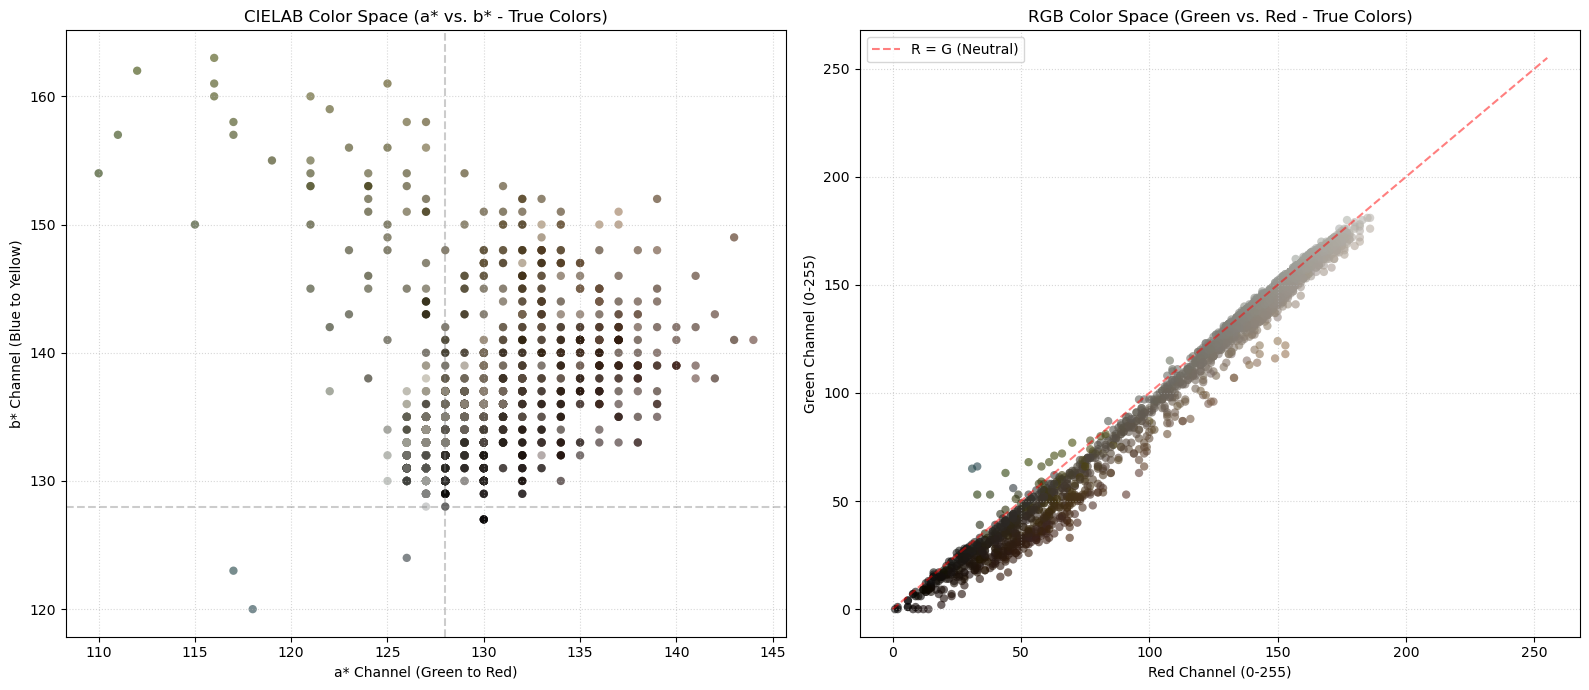

In [66]:
# 1. Sample pixels for clean and fast rendering
sample_rate = 200
r_sample = img_rgb[:, :, 0].ravel()[::sample_rate]
g_sample = img_rgb[:, :, 1].ravel()[::sample_rate]
b_sample = img_rgb[:, :, 2].ravel()[::sample_rate]
rgb_sample = img_rgb.reshape(-1, 3)[::sample_rate] / 255.0

a_sample = a_channel.ravel()[::sample_rate]
b_sample = b_channel.ravel()[::sample_rate]

# 2. Plot the scatter plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# CIELAB a* vs b* Scatter
axes[0].scatter(a_sample, b_sample, c=rgb_sample, alpha=0.6, edgecolors='none')
axes[0].set_title("CIELAB Color Space (a* vs. b* - True Colors)")
axes[0].set_xlabel("a* Channel (Green to Red)")
axes[0].set_ylabel("b* Channel (Blue to Yellow)")
axes[0].axvline(128, color='gray', linestyle='--', alpha=0.4)
axes[0].axhline(128, color='gray', linestyle='--', alpha=0.4)
axes[0].grid(True, linestyle=':', alpha=0.5)

# RGB Green vs Red Scatter
axes[1].scatter(r_sample, g_sample, c=rgb_sample, alpha=0.6, edgecolors='none')
axes[1].set_title("RGB Color Space (Green vs. Red - True Colors)")
axes[1].set_xlabel("Red Channel (0-255)")
axes[1].set_ylabel("Green Channel (0-255)")
axes[1].plot([0, 255], [0, 255], color='red', linestyle='--', alpha=0.5, label='R = G (Neutral)')
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

### Steps 3 & 4: 5D Color PCA Projection & Polarity Correction

Rather than using simple, fixed color indexes, we use **Principal Component Analysis (PCA)** on a 5-dimensional color feature space:
1. **L\* Channel**: Lightness (CIELAB)
2. **a\* Channel**: Green-to-Red color variation (CIELAB)
3. **b\* Channel**: Blue-to-Yellow color variation (CIELAB)
4. **Saturation Channel**: Chroma intensity (HSV)
5. **Hue Channel**: Color family angle (HSV)

Stacking these five channels creates a 5D feature representation per pixel. Running PCA on this space finds the axis of maximum variation (**PC1**), which dynamically combines color, brightness, saturation, and hue to isolate the leaves from the background (gray pipes, grids, and shadows).

We also apply **polarity correction**: we calculate the correlation between the projected PC1 values and the original a* channel values. If they are positively correlated, we flip PC1 (multiply by -1) to guarantee that green vegetation (which has low values in a*) always corresponds to the highest values in the scaled PC1 image.

In [67]:
# Flatten L*, a*, b*, Saturation and Hue channels for 5D PCA
l_flat = l_channel.astype(np.float32).reshape(-1, 1)
a_flat = a_channel.astype(np.float32).reshape(-1, 1)
b_flat = b_channel.astype(np.float32).reshape(-1, 1)
s_flat = s_channel.astype(np.float32).reshape(-1, 1)
h_flat = h_channel.astype(np.float32).reshape(-1, 1)
color_features = np.hstack((l_flat, a_flat, b_flat, s_flat, h_flat))

# Compute PCA using OpenCV's PCACompute2
mean, eigenvectors, eigenvalues = cv2.PCACompute2(color_features, mean=None)

# Project onto the first principal component (PC1)
projected = cv2.PCAProject(color_features, mean, eigenvectors)
pc1 = projected[:, 0].reshape(a_channel.shape)

# Polarity correction: ensure green (low values in a*) corresponds to high values in PC1
correlation = np.corrcoef(pc1.ravel(), a_channel.ravel())[0, 1]
if correlation > 0:
    pc1 = -pc1

# Scale to 0-255 range
pc1_min = pc1.min()
pc1_max = pc1.max()
pc1_scaled = np.uint8(255 * (pc1 - pc1_min) / (pc1_max - pc1_min + 1e-8))

# Calculate Explained Variance Ratio
total_variance = np.sum(eigenvalues)
var_ratios = (eigenvalues[:, 0] / total_variance) * 100

# Visualize PC1, its histogram, 2D PCA comparison, and 5D Explained Variance
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# 1. PC1 Grayscale Image
axes[0, 0].imshow(pc1_scaled, cmap='gray')
axes[0, 0].set_title("5D Polarity-Corrected PC1 Channel (L*, a*, b*, S, H)")
axes[0, 0].axis('off')

# 2. Histogram of PC1
axes[0, 1].hist(pc1_scaled.ravel(), bins=256, color='gray', range=[0, 256])
axes[0, 1].set_title("Histogram of 5D PC1 Values")
axes[0, 1].set_xlabel("Pixel Intensity (PC1)")
axes[0, 1].set_ylabel("Count")

# 3. 2D Color Scatter Plot (Without PCA - True Colors)
sample_rate = 200  # Sample pixels for clean and fast rendering
a_sample = a_channel.ravel()[::sample_rate]
b_sample = b_channel.ravel()[::sample_rate]
rgb_sample = img_rgb.reshape(-1, 3)[::sample_rate] / 255.0  # Normalize to [0,1]

axes[1, 0].scatter(a_sample, b_sample, c=rgb_sample, alpha=0.6, edgecolors='none')
axes[1, 0].set_title("2D Color Scatter Plot (Without PCA - True Colors)")
axes[1, 0].set_xlabel("a* Channel (Green to Red)")
axes[1, 0].set_ylabel("b* Channel (Blue to Yellow)")
axes[1, 0].axvline(128, color='gray', linestyle='--', alpha=0.4)
axes[1, 0].axhline(128, color='gray', linestyle='--', alpha=0.4)
axes[1, 0].grid(True, linestyle=':', alpha=0.5)

# 4. Explained Variance Scree Plot for all 5 components
pc_labels = [f'PC{i+1}' for i in range(len(var_ratios))]
bars = axes[1, 1].bar(pc_labels, var_ratios, color=['red', 'blue', 'orange', 'purple', 'brown'], alpha=0.7)
axes[1, 1].set_ylabel('Percentage of Explained Variance (%)')
axes[1, 1].set_title('5D PCA Scree Plot (Information Captured per Component)')
axes[1, 1].set_ylim(0, 110)
for bar in bars:
    yval = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

NameError: name 'h_channel' is not defined

### Steps 5 & 6: Otsu's Thresholding & Morphological Cleaning

We apply Otsu's thresholding to the scaled PC1 image to dynamically separate the foreground plants. We then clean the binary mask using morphological **opening** (removes small background noise/algae) and **closing** (fills small holes inside the leaf contours).

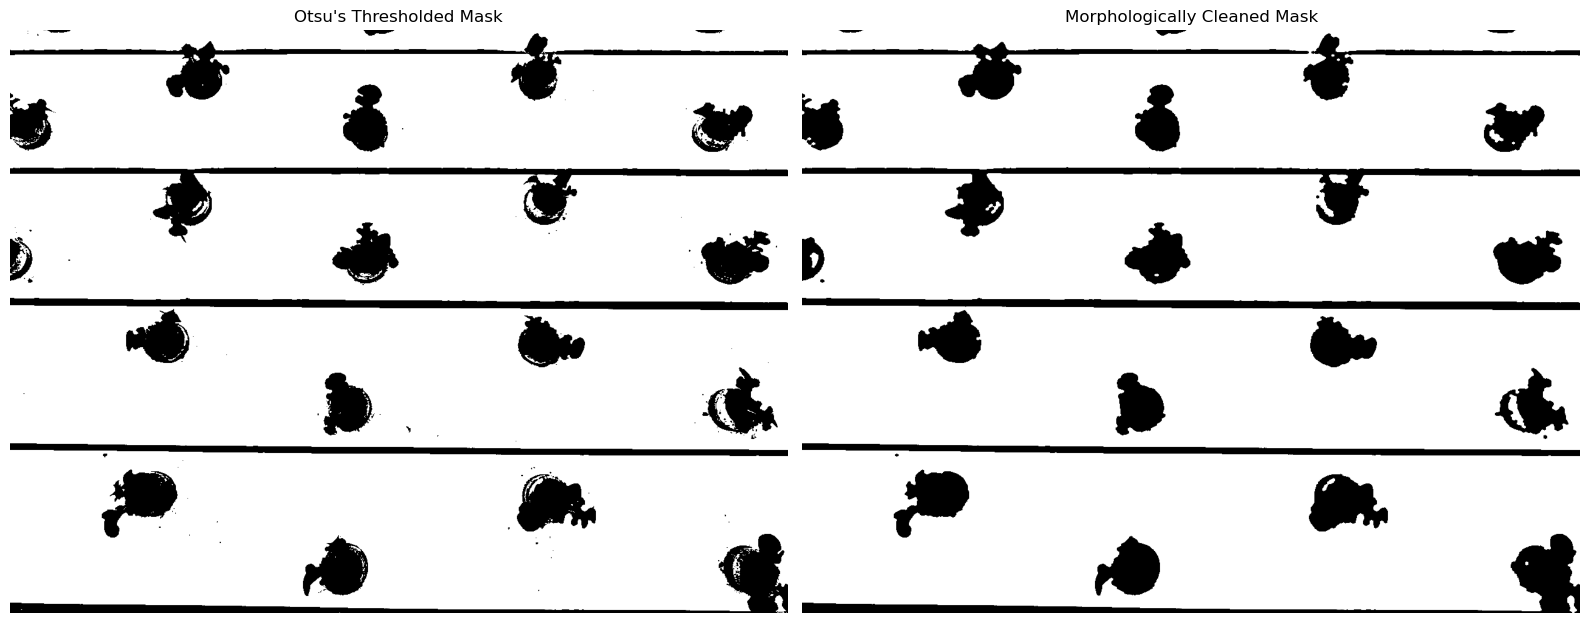

In [ ]:
# Otsu's Thresholding
_, binary_mask = cv2.threshold(pc1_scaled, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Morphological Cleaning
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
cleaned = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(binary_mask, cmap='gray')
axes[0].set_title("Otsu's Thresholded Mask")
axes[0].axis('off')

axes[1].imshow(cleaned, cmap='gray')
axes[1].set_title("Morphologically Cleaned Mask")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Step 7: Alternative Technique 1 - Adaptive Thresholding

Unlike Otsu's method which finds a single global threshold, **Adaptive Thresholding** calculates thresholds for small local neighborhoods of pixels. This helps handle non-uniform lighting conditions across the hydroponic grid.

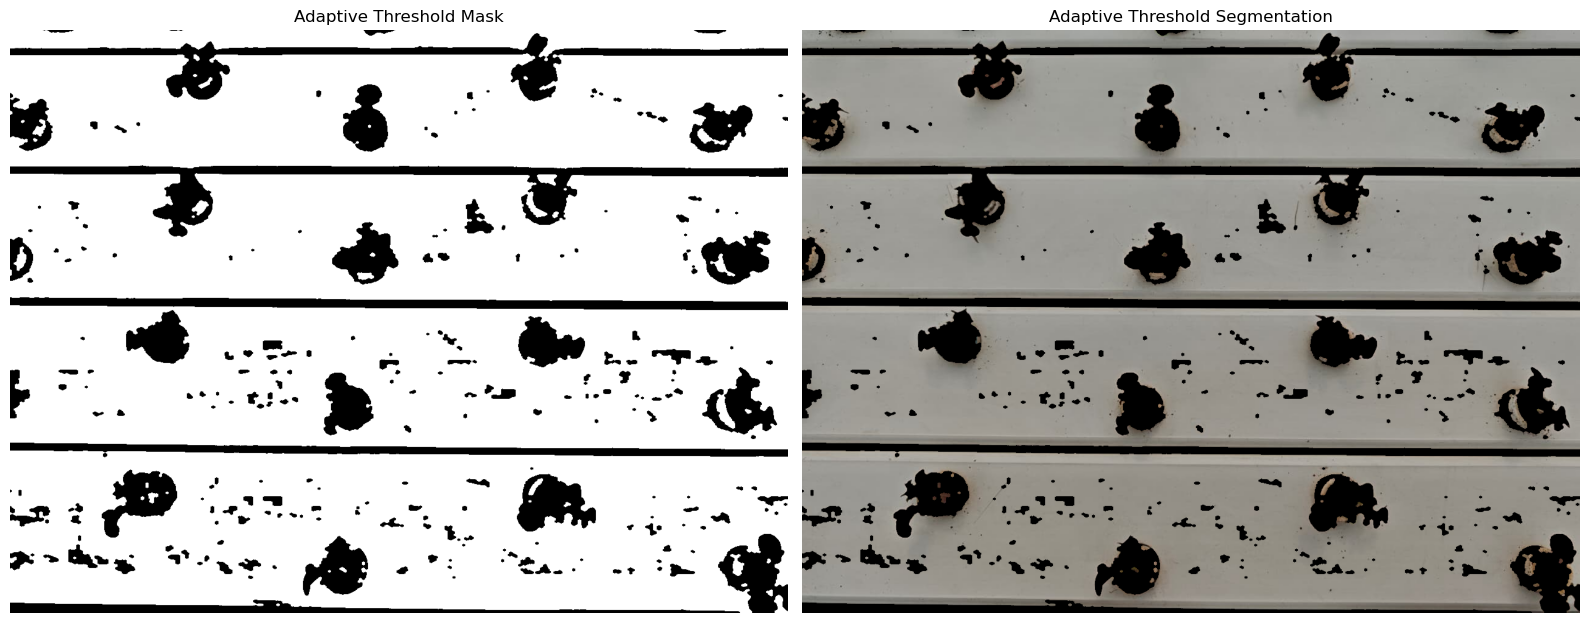

In [ ]:
# 1. Apply Adaptive Gaussian Thresholding on the PC1 channel
adaptive_mask = cv2.adaptiveThreshold(
    pc1_scaled, 
    255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, 
    101,  # Block size (neighborhood size)
    2     # Constant subtracted from the mean
)

# 2. Clean mask morphologically
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
cleaned = cv2.morphologyEx(adaptive_mask, cv2.MORPH_OPEN, kernel)
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

# Mask the original image
img_adaptive = cv2.bitwise_and(img_rgb, img_rgb, mask=cleaned)

# 3. Plot mask and segmented result
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(cleaned, cmap='gray')
axes[0].set_title("Adaptive Threshold Mask")
axes[0].axis('off')

axes[1].imshow(img_adaptive)
axes[1].set_title("Adaptive Threshold Segmentation")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Step 8: Alternative Technique 2 - K-Means Clustering

**K-Means Clustering** is an unsupervised algorithm that groups pixels into $K$ clusters based on color proximity. Here, we run K-Means with $K=2$ on our 4D color features (L*, a*, b*, S) to partition the image into "plants" and "background" without manually setting any threshold.

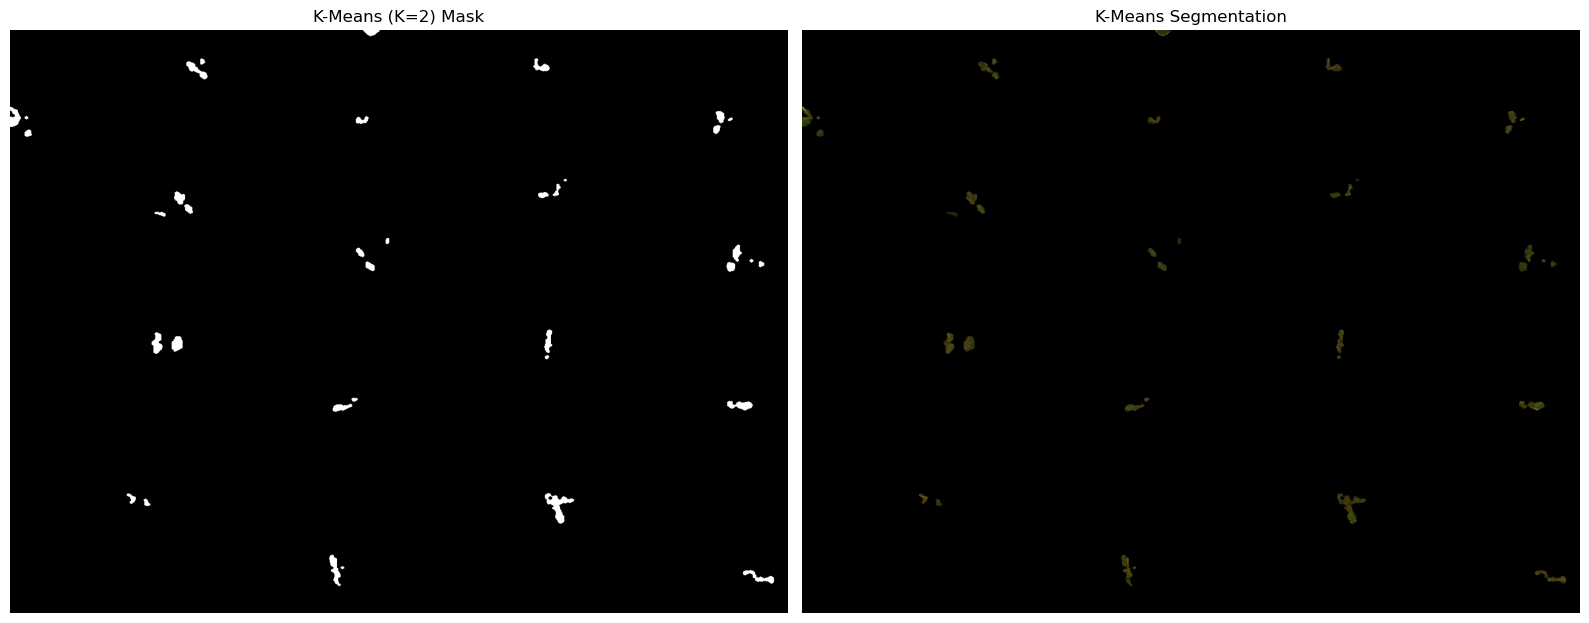

In [ ]:
# 1. Standardize features for K-Means (important for distance-based clustering)
features_std = (color_features - color_features.mean(axis=0)) / (color_features.std(axis=0) + 1e-8)
Z = features_std.astype(np.float32)

# 2. Define criteria and run K-Means (K=2)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 4
ret, label, center = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Reshape label back to 2D mask
kmeans_mask = label.reshape(a_channel.shape)

# Identify which cluster corresponds to the plant
# In our 4D space, the second channel is a* (index 1). Green leaves have lower a* values.
plant_cluster = np.argmin(center[:, 1])
kmeans_mask = np.uint8((kmeans_mask == plant_cluster) * 255)

# 3. Clean mask morphologically
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
cleaned = cv2.morphologyEx(kmeans_mask, cv2.MORPH_OPEN, kernel)
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

# Mask the original image
img_kmeans = cv2.bitwise_and(img_rgb, img_rgb, mask=cleaned)

# 4. Plot mask and segmented result
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(cleaned, cmap='gray')
axes[0].set_title("K-Means (K=2) Mask")
axes[0].axis('off')

axes[1].imshow(img_kmeans)
axes[1].set_title("K-Means Segmentation")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Step 9: Alternative Technique 3 - Watershed Segmentation

The **Watershed Algorithm** treats the image as a topographic surface. We use the distance transform of our binary mask to identify "sure foreground" markers (peaks/centers of plants) and "sure background" markers, and then flood the surface to find precise boundaries. This is especially useful for separating touching leaves.

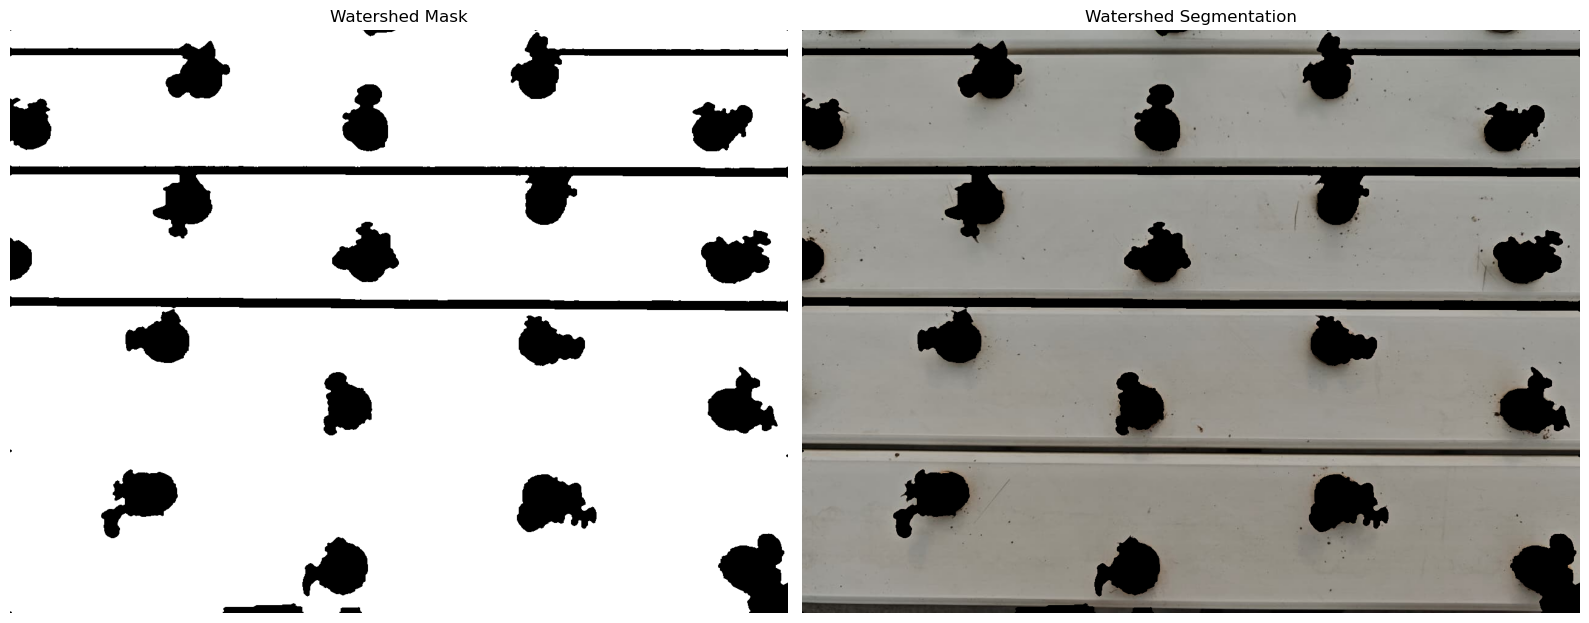

In [ ]:
if 'cleaned' not in locals():
    raise NameError("Segmentation mask 'cleaned' not found. Please execute one of the thresholding steps first.")

# 1. We use the cleaned Otsu mask as the starting point
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Finding sure background area (dilate the mask to make sure background is clear)
sure_bg = cv2.dilate(cleaned, kernel, iterations=3)

# 2. Finding sure foreground area (using distance transform)
dist_transform = cv2.distanceTransform(cleaned, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.1 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# 3. Finding unknown region (subtracting sure foreground from sure background)
unknown = cv2.subtract(sure_bg, sure_fg)

# 4. Marker labeling
_, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels so that sure background is not 0, but 1
markers = markers + 1

# Mark the unknown region with 0
markers[unknown == 255] = 0

# 5. Run Watershed on the RGB image
markers_ws = cv2.watershed(img_rgb, markers.copy())

# Create the final watershed segmentation mask (all labeled regions > 1)
watershed_mask = np.zeros_like(cleaned)
watershed_mask[markers_ws > 1] = 255

# Clean mask morphologically
watershed_cleaned = cv2.morphologyEx(watershed_mask, cv2.MORPH_OPEN, kernel)
watershed_cleaned = cv2.morphologyEx(watershed_cleaned, cv2.MORPH_CLOSE, kernel)

# Mask the original image
img_watershed = cv2.bitwise_and(img_rgb, img_rgb, mask=watershed_cleaned)

# 6. Plot mask and segmented result
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(watershed_cleaned, cmap='gray')
axes[0].set_title("Watershed Mask")
axes[0].axis('off')

axes[1].imshow(img_watershed)
axes[1].set_title("Watershed Segmentation")
axes[1].axis('off')

plt.tight_layout()
plt.show()